In [1]:
import os
os.environ.pop("CUDA_VISIBLE_DEVICES", None)


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from transformers import AutoImageProcessor, ViTModel
from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image

2026-01-18 21:53:55.925752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-18 21:53:55.944836: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-18 21:53:55.950888: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-18 21:53:55.964464: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-01-18 21:53:56.728440: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root (folder containing '0_dataset_prep'). cwd={start}")

ROOT = find_dataset_root()

CSV_PATH   = ROOT / "0_dataset_prep" / "out" / "metadata" / "colonoscopy_metadata.csv"
IMG_DIR  = ROOT / "0_dataset_prep" / "out" / "images"                            

df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head(3))

CSV shape: (42126, 7)
Columns: ['source', 'question', 'answer', 'img_id', 'question_norm', 'question_type', 'answer_type']
               source                                           question  \
0  Ulcerative Colitis  Are there any abnormalities in the image? Chec...   
1  Ulcerative Colitis  Are there any anatomical landmarks in the imag...   
2  Ulcerative Colitis  Are there any instruments in the image? Check ...   

               answer                     img_id  \
0  ulcerative colitis  cla820gl0s3nv071u4fgd7xgq   
1                none  cla820gl0s3nv071u4fgd7xgq   
2                none  cla820gl0s3nv071u4fgd7xgq   

                                       question_norm question_type answer_type  
0  are there any abnormalities in the image check...        Yes/No       Token  
1  are there any anatomical landmarks in the imag...        Yes/No     None/NA  
2  are there any instruments in the image check a...        Yes/No     None/NA  


In [4]:
IMG_DIR = Path(IMG_DIR)
EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def resolve_img_path(img_id: str):
    for ext in EXTS:
        p = IMG_DIR / f"{img_id}{ext}"
        if p.exists():
            return str(p)
    return None

df["image_path"] = df["img_id"].apply(resolve_img_path)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)
print("After attaching paths:", df.shape)

After attaching paths: (42126, 8)


Create answer_norm; filter yes/no → print subset size + counts

In [5]:
df["answer_norm"] = df["answer"].astype(str).str.strip().str.lower()
yn_df = df[df["answer_norm"].isin(["yes", "no"])].copy()

print("Yes/No subset:", yn_df.shape, Counter(yn_df["answer_norm"]))

Yes/No subset: (12267, 9) Counter({'yes': 6272, 'no': 5995})


Balance to MAX_PER_CLASS=1200 each → print balanced size + counts

In [6]:
MAX_PER_CLASS = None  # use full yes/no data (set an int to subsample per class)
balanced = []
for lab, grp in yn_df.groupby("answer_norm"):
    if MAX_PER_CLASS is None:
        balanced.append(grp)
    else:
        balanced.append(grp.sample(min(MAX_PER_CLASS, len(grp)), random_state=42))
yn_df = pd.concat(balanced).sample(frac=1, random_state=42).reset_index(drop=True)
print("Balanced subset:", yn_df.shape, Counter(yn_df["answer_norm"]))


Balanced subset: (12267, 9) Counter({'yes': 6272, 'no': 5995})


Map labels {no:0, yes:1}; stratified train/test split → print sizes

In [7]:
label_map = {"no": 0, "yes": 1}
yn_df["label"] = yn_df["answer_norm"].map(label_map)

train_df, test_df = train_test_split(
    yn_df[["image_path", "label", "question", "answer"]],
    test_size=0.2,
    random_state=42,
    stratify=yn_df["label"]
)
print("Train/Test sizes:", train_df.shape, test_df.shape)

Train/Test sizes: (9813, 4) (2454, 4)


# CNN Baseline 

In [8]:
TARGET_SIZE = (128, 128)
BATCH_SIZE  = 16
AUTOTUNE    = tf.data.AUTOTUNE

def load_img_tf(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, TARGET_SIZE)
    img = img / 255.0
    return img, label

def make_ds(frame, shuffle=False):
    paths = frame["image_path"].values
    labels = frame["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(frame), seed=42)
    ds = ds.map(load_img_tf, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, shuffle=True)
test_ds  = make_ds(test_df, shuffle=False)

cnn = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(2, activation="softmax")
])

cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("\n[ CNN ] training…")
cnn.fit(train_ds, validation_data=test_ds, epochs=2, verbose=1)

I0000 00:00:1768791239.540138  678079 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-18 21:53:59.541858: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



[ CNN ] training…
Epoch 1/2


/home/aristotle/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  1/614 ━━━━━━━━━━━━━━━━━━━━ 10:34 1s/step - accuracy: 0.5625 - loss: 0.6951

  2/614 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - accuracy: 0.5938 - loss: 0.6789

...

608/614 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7099 - loss: 0.4953

610/614 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7099 - loss: 0.4953

612/614 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7099 - loss: 0.4953

614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7099 - loss: 0.4953

614/614 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7140 - loss: 0.4927 - val_accuracy: 0.7021 - val_loss: 0.5081



[ CNN ] classification report
              precision    recall  f1-score   support

          no       0.90      0.44      0.59      1199
         yes       0.64      0.95      0.77      1255

    accuracy                           0.70      2454
   macro avg       0.77      0.70      0.68      2454
weighted avg       0.77      0.70      0.68      2454



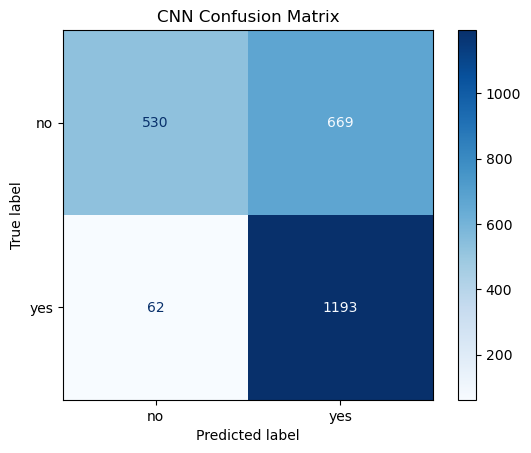

In [9]:
y_pred_cnn = np.argmax(cnn.predict(test_ds, verbose=0), axis=1)
y_true     = test_df["label"].values
print("\n[ CNN ] classification report")
print(classification_report(y_true, y_pred_cnn, target_names=["no","yes"]))
cm = confusion_matrix(y_true, y_pred_cnn)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("CNN Confusion Matrix"); plt.show()

acc_cnn = accuracy_score(y_true, y_pred_cnn)
f1_cnn  = f1_score(y_true, y_pred_cnn, average="macro")

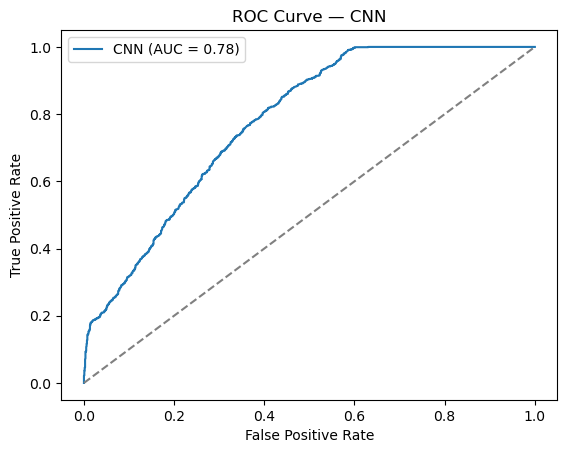

In [10]:
from sklearn.metrics import roc_curve, auc

y_score = cnn.predict(test_ds, verbose=0)[:,1]  
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"CNN (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — CNN")
plt.legend()
plt.show()

# ViT + Logistic Regression


[ ViT ] extracting frozen features on full train/test


/home/aristotle/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



[ ViT ] classification report
              precision    recall  f1-score   support

          no       0.69      0.57      0.62      1199
         yes       0.64      0.75      0.69      1255

    accuracy                           0.66      2454
   macro avg       0.67      0.66      0.66      2454
weighted avg       0.66      0.66      0.66      2454



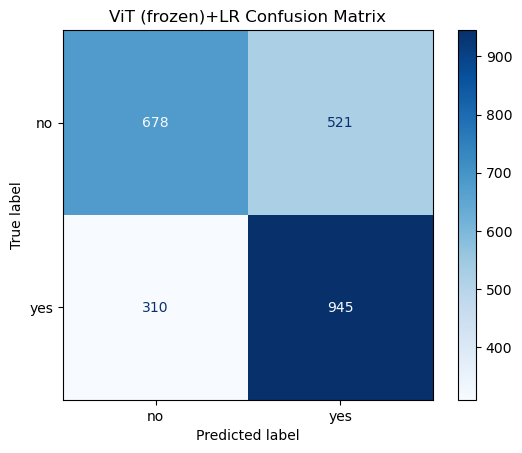

In [11]:
print("\n[ ViT ] extracting frozen features on full train/test")
train_v = train_df  # full train
test_v  = test_df   # full test

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

vit_name = "google/vit-base-patch16-224-in21k"
vit_proc = AutoImageProcessor.from_pretrained(vit_name)
vit      = ViTModel.from_pretrained(vit_name).to(DEVICE)

def vit_embed(paths):
    # returns CLS embeddings
    batch = []
    feats = []
    for p in paths:
        im = Image.open(p).convert("RGB")
        batch.append(vit_proc(images=im, return_tensors="pt"))
        if len(batch) == 8:
            inp = {k: torch.cat([b[k] for b in batch], dim=0).to(DEVICE) for k in batch[0]}
            with torch.no_grad():
                out = vit(**inp).last_hidden_state[:,0,:].cpu().numpy()
            feats.append(out)
            batch = []
    if batch:
        inp = {k: torch.cat([b[k] for b in batch], dim=0).to(DEVICE) for k in batch[0]}
        with torch.no_grad():
            out = vit(**inp).last_hidden_state[:,0,:].cpu().numpy()
        feats.append(out)
    return np.vstack(feats)

X_train_vit = vit_embed(train_v["image_path"].tolist())
y_train_vit = train_v["label"].values
X_test_vit  = vit_embed(test_v["image_path"].tolist())
y_test_vit  = test_v["label"].values

clf_vit = LogisticRegression(max_iter=200, n_jobs=1)
clf_vit.fit(X_train_vit, y_train_vit)
y_pred_vit = clf_vit.predict(X_test_vit)

print("\n[ ViT ] classification report")
print(classification_report(y_test_vit, y_pred_vit, target_names=["no","yes"]))
cm = confusion_matrix(y_test_vit, y_pred_vit)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("ViT (frozen)+LR Confusion Matrix"); plt.show()

acc_vit = accuracy_score(y_test_vit, y_pred_vit)
f1_vit  = f1_score(y_test_vit, y_pred_vit, average="macro")


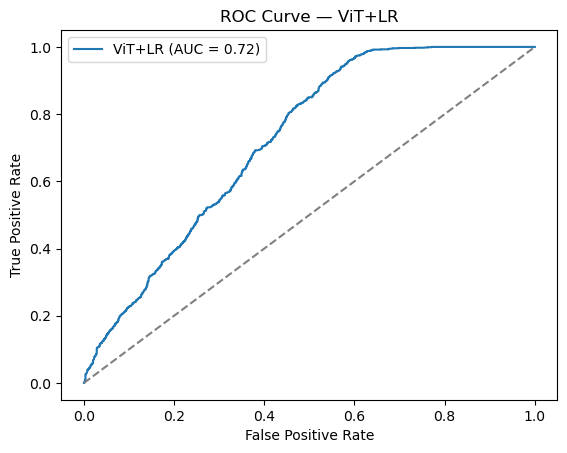

In [12]:
from sklearn.metrics import roc_curve, auc

y_score_vit = clf_vit.predict_proba(X_test_vit)[:,1]
fpr, tpr, _ = roc_curve(y_test_vit, y_score_vit)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ViT+LR (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ViT+LR")
plt.legend()
plt.show()

# BLIP VQA (zero/few-shot) mapped to yes/no


[ BLIP VQA ] evaluating full test set (maps to yes/no)


/home/aristotle/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



[ BLIP ] classification report
              precision    recall  f1-score   support

          no       0.50      0.34      0.40      1199
         yes       0.52      0.67      0.58      1255

    accuracy                           0.51      2454
   macro avg       0.51      0.51      0.49      2454
weighted avg       0.51      0.51      0.50      2454



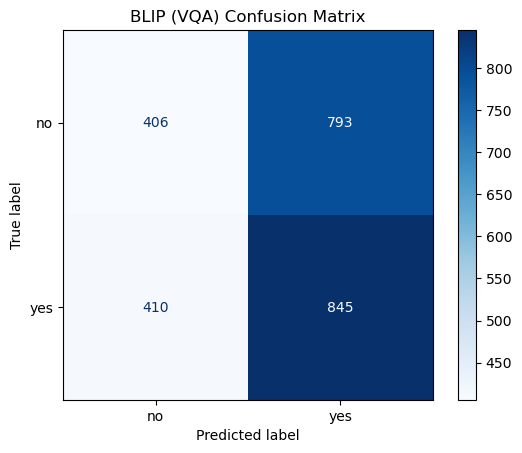

In [13]:
print("\n[ BLIP VQA ] evaluating full test set (maps to yes/no)")
blip_name = "Salesforce/blip-vqa-base"
blip_proc = BlipProcessor.from_pretrained(blip_name)
blip      = BlipForQuestionAnswering.from_pretrained(blip_name).to(DEVICE)

sample_blip = test_df.reset_index(drop=True)  # full test set

def to_yesno(text):
    t = str(text).lower()
    if "yes" in t:
        return 1
    if "no" in t:
        return 0
    return 0

preds_blip, true_blip = [], []
for _, row in sample_blip.iterrows():
    q = str(row["question"]) if isinstance(row["question"], str) and len(str(row["question"]).strip())>0 else "Is the answer yes or no?"
    im = Image.open(row["image_path"]).convert("RGB")
    inputs = blip_proc(images=im, text=q, return_tensors="pt").to(DEVICE)
    out = blip.generate(**inputs, max_new_tokens=10)
    txt = blip_proc.decode(out[0], skip_special_tokens=True)
    preds_blip.append(to_yesno(txt))
    true_blip.append(row["label"])

y_true_blip = np.array(true_blip)
y_pred_blip = np.array(preds_blip)

print("\n[ BLIP ] classification report")
print(classification_report(y_true_blip, y_pred_blip, target_names=["no","yes"]))
cm = confusion_matrix(y_true_blip, y_pred_blip)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("BLIP (VQA) Confusion Matrix"); plt.show()

acc_blip = accuracy_score(y_true_blip, y_pred_blip)
f1_blip  = f1_score(y_true_blip, y_pred_blip, average="macro")


# Decision Tree

In [14]:
!pip install scikit-image

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


HOG (Histogram of Oriented Gradients) - didn't work 


[ Decision Tree (HOG features) ] classification report
              precision    recall  f1-score   support

          no       0.50      0.57      0.53      1199
         yes       0.53      0.46      0.49      1255

    accuracy                           0.51      2454
   macro avg       0.52      0.52      0.51      2454
weighted avg       0.52      0.51      0.51      2454



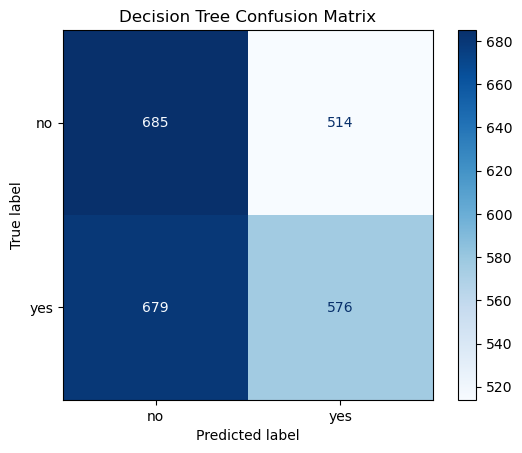

In [15]:
from sklearn.tree import DecisionTreeClassifier
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize


def extract_hog(path, target_size=(128, 128)):
    img = imread(path)
    img = resize(img, target_size, anti_aliasing=True)
    img = rgb2gray(img)
    hog_feat = hog(img, pixels_per_cell=(16,16), cells_per_block=(2,2), visualize=False)
    return hog_feat

# Extract HOG features (consistent length)
train_feats = [extract_hog(p) for p in train_df["image_path"]]
test_feats  = [extract_hog(p) for p in test_df["image_path"]]

X_train_hog = np.vstack(train_feats)
y_train_hog = train_df["label"].values

X_test_hog  = np.vstack(test_feats)
y_test_hog  = test_df["label"].values


tree = DecisionTreeClassifier(max_depth=20, random_state=42)
tree.fit(X_train_hog, y_train_hog)
y_pred_tree = tree.predict(X_test_hog)

print("\n[ Decision Tree (HOG features) ] classification report")
print(classification_report(y_test_hog, y_pred_tree, target_names=["no","yes"]))

cm = confusion_matrix(y_test_hog, y_pred_tree)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix"); plt.show()

acc_tree = accuracy_score(y_test_hog, y_pred_tree)
f1_tree  = f1_score(y_test_hog, y_pred_tree, average="macro")


# Comparison table 

In [16]:
results = pd.DataFrame([
    {"Model": "Tiny CNN (from scratch)", "Accuracy": acc_cnn, "Macro-F1": f1_cnn, "Notes": f"{len(train_df)} train / {len(test_df)} test"},
    {"Model": "ViT (frozen) + LR",       "Accuracy": acc_vit, "Macro-F1": f1_vit, "Notes": f"{len(train_v)} train / {len(test_v)} test"},
    {"Model": "BLIP (VQA, zero-shot)",   "Accuracy": acc_blip,"Macro-F1": f1_blip,"Notes": f"{len(sample_blip)} VQA eval"},
    {"Model": "Decision Tree (HOG)",     "Accuracy": acc_tree,"Macro-F1": f1_tree,"Notes": f"{len(train_df)} train / {len(test_df)} test"}
])
print("\n=== Comparison ===")
print(results.to_string(index=False))



=== Comparison ===
                  Model  Accuracy  Macro-F1                  Notes
Tiny CNN (from scratch)  0.702119  0.678664 9813 train / 2454 test
      ViT (frozen) + LR  0.661369  0.657313 9813 train / 2454 test
  BLIP (VQA, zero-shot)  0.509780  0.493573          2454 VQA eval
    Decision Tree (HOG)  0.513855  0.512894 9813 train / 2454 test
